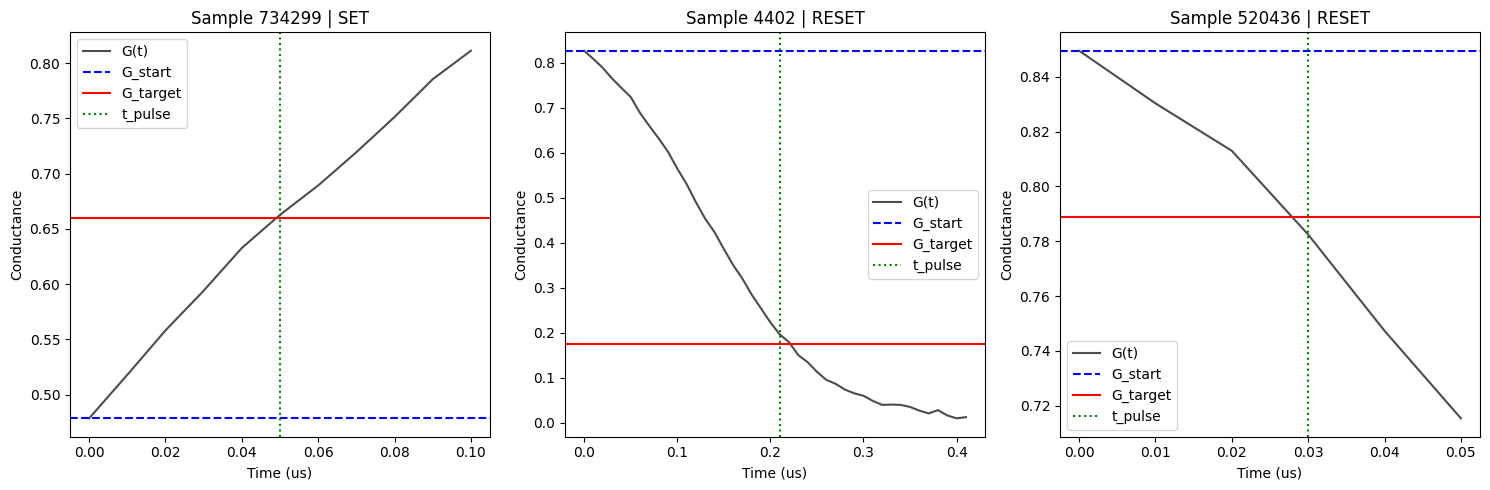

In [1]:
import torch
import matplotlib.pyplot as plt
import random

def verify_data(data_path='data/train.pt', num_plots=3):
    data = torch.load(data_path)
    plt.figure(figsize=(15, 5))
    
    indices = random.sample(range(len(data)), num_plots)
    
    for i, idx in enumerate(indices):
        sample = data[idx]
        g_history = sample['g_history'].numpy()
        g_start = sample['g_start']
        g_target = sample['g_target']
        t_pulse = sample['t_pulse']
        
        time_axis = [j * 0.01 for j in range(len(g_history))]
        t_pulse_us = t_pulse * 1e6
        
        plt.subplot(1, num_plots, i + 1)
        plt.plot(time_axis, g_history, label='G(t)', color='black', alpha=0.7)
        plt.axhline(y=g_start, color='blue', linestyle='--', label='G_start')
        plt.axhline(y=g_target, color='red', linestyle='-', label='G_target')
        plt.axvline(x=t_pulse_us, color='green', linestyle=':', label='t_pulse')
        
        plt.title(f"Sample {idx} | {'SET' if sample['direction'] > 0 else 'RESET'}")
        plt.xlabel("Time (us)")
        plt.ylabel("Conductance")
        plt.legend()
        
    plt.tight_layout()

if __name__ == "__main__":
    verify_data()

In [2]:
import torch
import os
import sys

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.append(project_root)

from core.vcm_simulator import VCMSimulator
from baseline.model import NPPModel

def run_benchmark(num_samples=10000, rpd_one_shot=0.50, rpd_iterative=0.05, max_steps=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    simulator = VCMSimulator(device=device)

    model = NPPModel().to(device)
    model.load_state_dict(torch.load(os.path.join(current_dir, 'npp_final.pth'), map_location=device))
    model.eval()

    g_curr = torch.empty(num_samples, 1, device=device).uniform_(simulator.g_min, simulator.g_max)
    g_target = torch.empty(num_samples, 1, device=device).uniform_(simulator.g_min, simulator.g_max)

    invalid_mask = (torch.abs(g_target - g_curr) / g_target <= rpd_iterative).squeeze(1)
    while invalid_mask.any():
        num_invalid = invalid_mask.sum().item()
        g_curr[invalid_mask] = torch.empty(num_invalid, 1, device=device).uniform_(simulator.g_min, simulator.g_max)
        g_target[invalid_mask] = torch.empty(num_invalid, 1, device=device).uniform_(simulator.g_min, simulator.g_max)
        invalid_mask = (torch.abs(g_target - g_curr) / g_target <= rpd_iterative).squeeze(1)

    steps_taken = torch.zeros(num_samples, 1, device=device)
    success = torch.zeros(num_samples, 1, dtype=torch.bool, device=device)
    one_shot_success = torch.zeros(num_samples, 1, dtype=torch.bool, device=device)

    t_scale = 1e-6

    for step in range(1, max_steps + 1):
        active_mask = ~success
        if not active_mask.any():
            break

        with torch.no_grad():
            out = model(g_curr, g_target)

        t_pulse = torch.abs(out) * t_scale
        t_pulse = torch.clamp(t_pulse, 0.0, 2e-6)
        
        i_t = torch.sign(g_target - g_curr)

        g_next = simulator.simulate_pulse(g_curr, i_t, t_pulse, record_history=False)
        g_curr = torch.where(active_mask, g_next, g_curr)

        current_rpd = torch.abs(g_target - g_curr) / g_target
        
        if step == 1:
            one_shot_success = current_rpd <= rpd_one_shot

        just_succeeded = active_mask & (current_rpd <= rpd_iterative)
        success = success | just_succeeded
        steps_taken = torch.where(just_succeeded, step * torch.ones_like(steps_taken), steps_taken)

    steps_taken[~success] = max_steps

    print("\n================================================")
    print("                (Ouroboros Protocol)              ")
    print("================================================")
    print(f"One-shot Success (< {int(rpd_one_shot*100)}% RPD): {(one_shot_success.float().mean().item() * 100):.2f}%")
    print(f"Iterative Success (< {int(rpd_iterative*100)}% RPD): {(success.float().mean().item() * 100):.2f}%")
    print(f"Average Steps Taken:          {steps_taken.float().mean().item():.2f}")
    print("================================================")

if __name__ == "__main__":
    run_benchmark()


                (Ouroboros Protocol)              
One-shot Success (< 50% RPD): 97.72%
Iterative Success (< 5% RPD): 73.44%
Average Steps Taken:          3.59
